## Imports

In [238]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              f1_score, precision_score, recall_score, roc_auc_score,
                                r2_score, mean_absolute_error, mean_squared_error)
import xgboost as xgb

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

In [79]:
customer = pd.read_csv('Raw_Data/customer.csv')
order = pd.read_csv('Raw_Data/order.csv')
order_detail = pd.read_csv('Raw_Data/order_detail.csv')
product = pd.read_csv('Raw_Data/product.csv')
returned = pd.read_csv('Raw_Data/returned.csv')
shipping = pd.read_csv('Raw_Data/shipping.csv')

returned["Returned"] = 1

df = order_detail.merge(order, on="Order ID", how="left")
df = df.merge(product, on="Product ID", how="left")
df = df.merge(customer, on="Customer ID", how="left")
df = df.merge(shipping, on="Order ID", how="left")
df = df.merge(returned, on="Order ID", how="left")

df["Returned"] = df["Returned"].fillna(0).astype(int)
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df.head()

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost,Customer ID,Order Priority,...,Customer Name,Segment,Shipping ID,Ship Date,Ship Mode,City,State,Country,Region,Returned
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033,SC-20575,Medium,...,Sonia Cooley,Consumer,44634,2014-10-06,Standard Class,Mexico City,Distrito Federal,Mexico,North,0
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20,Standard Class,Dos Quebradas,Risaralda,Colombia,South,0
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20,Standard Class,Dos Quebradas,Risaralda,Colombia,South,0
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20,Standard Class,Dos Quebradas,Risaralda,Colombia,South,0
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20,Standard Class,Dos Quebradas,Risaralda,Colombia,South,0


#  Shipping-Delay Prediction
`Shipping_Days` = days between order and ship date, ranging from 0 to 7 in this data.ct.n.

count    49670.000000
mean         3.972116
std          1.727310
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: Shipping_Days, dtype: float64


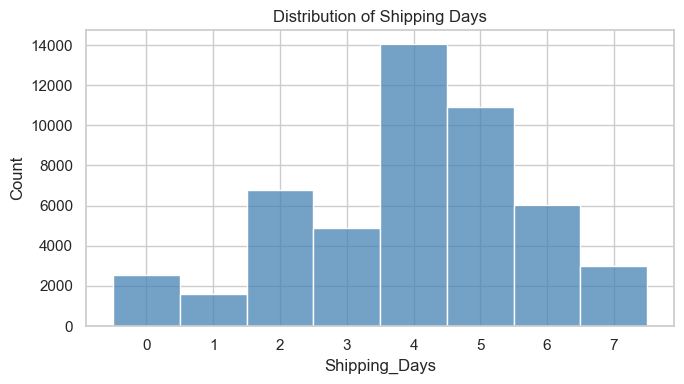

In [213]:
df["Shipping_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print(df["Shipping_Days"].describe())

plt.figure(figsize=(7, 4))
sns.histplot(df["Shipping_Days"], bins=8, color="steelblue", discrete=True)
plt.title("Distribution of Shipping Days")
plt.tight_layout()
plt.show()

### `Ship Mode` — feature or leakage?

I assumed that **"The customer already chose a shipping method — how many days will delivery actually take?"** — this is the classic "arrives by date" estimate shown at checkout on most e-commerce sites. Here `Ship Mode` is a legitimate, already-known input, not leakage.

`Shipping Cost` is still excluded — knowing the exact charged cost isn't standard checkout-time information (only the mode/tier the customer picked is).

In [217]:
print(df.groupby("Ship Mode", observed=True)["Shipping_Days"].agg(["mean", "std", "min", "max"]))
print()
print(df.groupby("Order Priority", observed=True)["Shipping_Days"].mean())

                    mean       std  min  max
Ship Mode                                   
First Class     2.186947  0.749429    1    3
Same Day        0.037405  0.189787    0    1
Second Class    3.235058  1.173668    2    5
Standard Class  4.996348  1.002002    4    7

Order Priority
Critical    1.815070
High        3.085783
Low         6.491183
Medium      4.518817
Name: Shipping_Days, dtype: float64


## Feature engineering

Order economics, product/customer categorical info, geography, order timing, and now `Ship Mode` (per the framing above).

In [220]:
df["Order_Month"] = df["Order Date"].dt.month
df["Order_DayOfWeek"] = df["Order Date"].dt.dayofweek

features_num = ["Sales", "Quantity", "Discount", "Order_Month", "Order_DayOfWeek"]
features_cat = ["Order Priority", "Category", "Sub-Category", "Segment", "Market", "Region", "Ship Mode"]

X = df[features_num + features_cat]
y = df["Shipping_Days"]

X.head()

,Sales,Quantity,Discount,Order_Month,Order_DayOfWeek,Order Priority,Category,Sub-Category,Segment,Market,Region,Ship Mode
0,13.08,3,0.0,10,3,Medium,Office Supplies,Labels,Consumer,LATAM,North,Standard Class
1,252.16,8,0.0,10,0,Medium,Furniture,Furnishings,Consumer,LATAM,South,Standard Class
2,193.28,2,0.0,10,0,Medium,Furniture,Bookcases,Consumer,LATAM,South,Standard Class
3,35.44,4,0.0,10,0,Medium,Office Supplies,Binders,Consumer,LATAM,South,Standard Class
4,71.60,2,0.0,10,0,Medium,Office Supplies,Art,Consumer,LATAM,South,Standard Class


In [222]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 39736  Test size: 9934


In [224]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), features_num),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features_cat),
])

In [240]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=200, random_state=42),
}

predictions = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    predictions[name] = pipe.predict(X_test)

In [242]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_prep, y_train)
predictions["XGBoost"] = xgb_model.predict(X_test_prep)

In [244]:
comparison = pd.DataFrame({
    name: {
        "R2": r2_score(y_test, pred),
        "MAE (days)": mean_absolute_error(y_test, pred),
        "RMSE (days)": mean_squared_error(y_test, pred) ** 0.5,
    }
    for name, pred in predictions.items()
}).T.sort_values("R2", ascending=False)

comparison.round(3)

,R2,MAE (days),RMSE (days)
Random Forest,0.770,0.654,0.834
HistGradientBoosting,0.769,0.660,0.836
XGBoost,0.768,0.661,0.838
Decision Tree,0.764,0.660,0.845
Linear Regression,0.757,0.685,0.858


In [250]:
train_predictions = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    train_predictions[name] = pipe.predict(X_train)

X_train_prep2 = preprocessor.fit_transform(X_train)
xgb_model2 = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model2.fit(X_train_prep2, y_train)
train_predictions["XGBoost"] = xgb_model2.predict(X_train_prep2)

comparison_train_test = pd.DataFrame({
    name: {
        "R2 (Train)": r2_score(y_train, train_predictions[name]),
        "R2 (Test)": r2_score(y_test, predictions[name]),
        "MAE (Train)": mean_absolute_error(y_train, train_predictions[name]),
        "MAE (Test)": mean_absolute_error(y_test, predictions[name]),
    }
    for name in predictions
}).T.sort_values("R2 (Test)", ascending=False)

comparison_train_test.round(3)

,R2 (Train),R2 (Test),MAE (Train),MAE (Test)
Random Forest,0.779,0.770,0.633,0.654
HistGradientBoosting,0.775,0.769,0.648,0.660
XGBoost,0.779,0.768,0.640,0.661
Decision Tree,0.763,0.764,0.656,0.660
Linear Regression,0.748,0.757,0.692,0.685


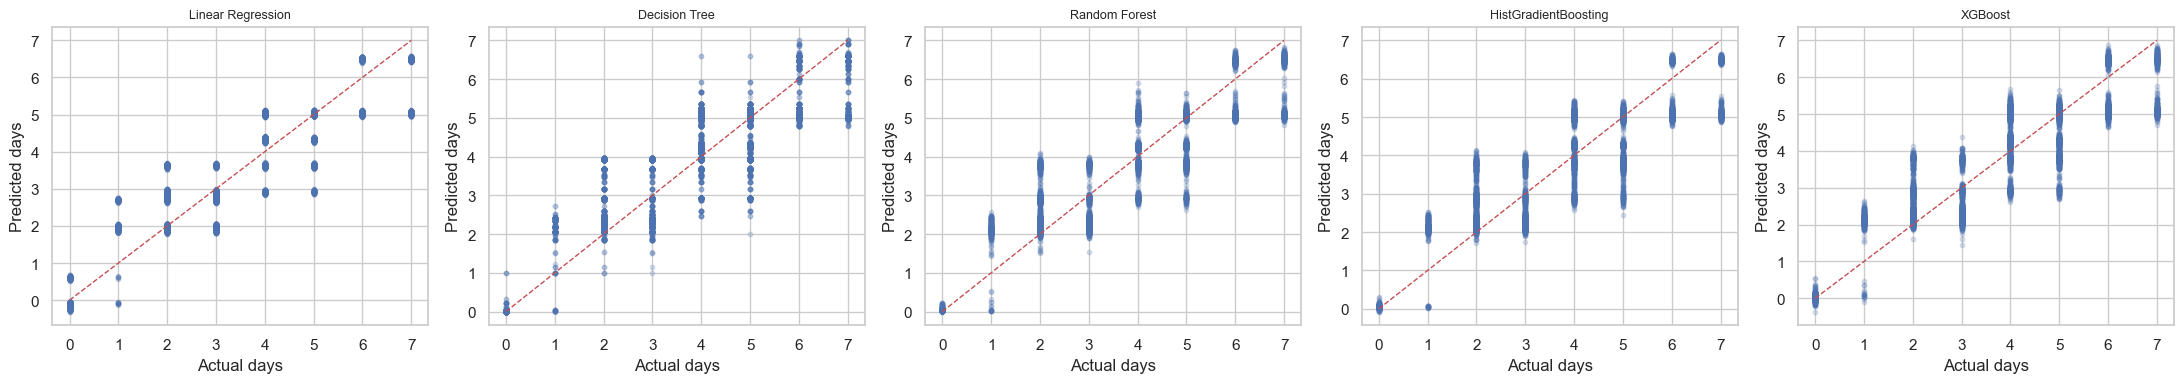

In [246]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, pred, alpha=0.2, s=10)
    ax.plot([0, 7], [0, 7], "r--", linewidth=1)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Actual days")
    ax.set_ylabel("Predicted days")
plt.tight_layout()
plt.show()

# Customer Segmentation

**Goal:** group customers into meaningful types using  Recency, Frequency, Monetary plus two extra behavioral signals: average discount used and return rate.

In [103]:
reference_date = df["Order Date"].max() + pd.Timedelta(days=1)

customer_features = df.groupby("Customer ID").agg(
    Recency=("Order Date", lambda x: (reference_date - x.max()).days),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum"),
    Avg_Discount=("Discount", "mean"),
    Return_Rate=("Returned", "mean"),
).reset_index()

customer_features.describe()

,Recency,Frequency,Monetary,Avg_Discount,Return_Rate
count,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000
mean,88.655129,15.753933,7622.121115,0.152608,0.036513
std,130.699819,10.344531,6673.367954,0.109090,0.061696
min,1.000000,1.000000,7.173000,0.000000,0.000000
25%,15.000000,6.000000,1610.862000,0.087500,0.000000
50%,37.000000,14.000000,5862.870000,0.136604,0.000000
75%,104.000000,25.000000,12593.454000,0.190909,0.057971
max,1207.000000,41.000000,33933.127500,0.700000,0.436620


`Recency` and `Monetary` are right-skewed, so a `log1p` transform is applied to those two before scaling all five features.

In [106]:
customer_features["Recency_log"] = np.log1p(customer_features["Recency"])
customer_features["Monetary_log"] = np.log1p(customer_features["Monetary"])

cluster_cols = ["Recency_log", "Frequency", "Monetary_log", "Avg_Discount", "Return_Rate"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_features[cluster_cols])

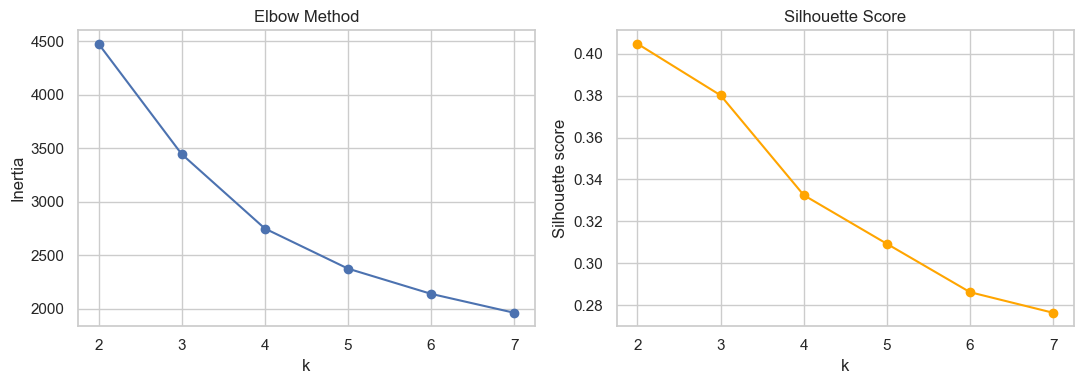

In [108]:
inertia, silhouette = [], []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertia, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

The elbow bends around **k=3-4**; going with **k=3** keeps the segments simple enough to act on.

In [111]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_features["Cluster"] = kmeans.fit_predict(X_scaled)

profile_cols = ["Recency", "Frequency", "Monetary", "Avg_Discount", "Return_Rate"]
cluster_summary = customer_features.groupby("Cluster")[profile_cols].mean().round(2)
cluster_summary["Count"] = customer_features["Cluster"].value_counts().sort_index()
cluster_summary

,Recency,Frequency,Monetary,Avg_Discount,Return_Rate,Count
Cluster,,,,,,
0,29.67,25.39,13283.02,0.14,0.07,788
1,178.76,5.81,1490.16,0.34,0.00,264
2,130.91,6.50,2329.85,0.08,0.00,537


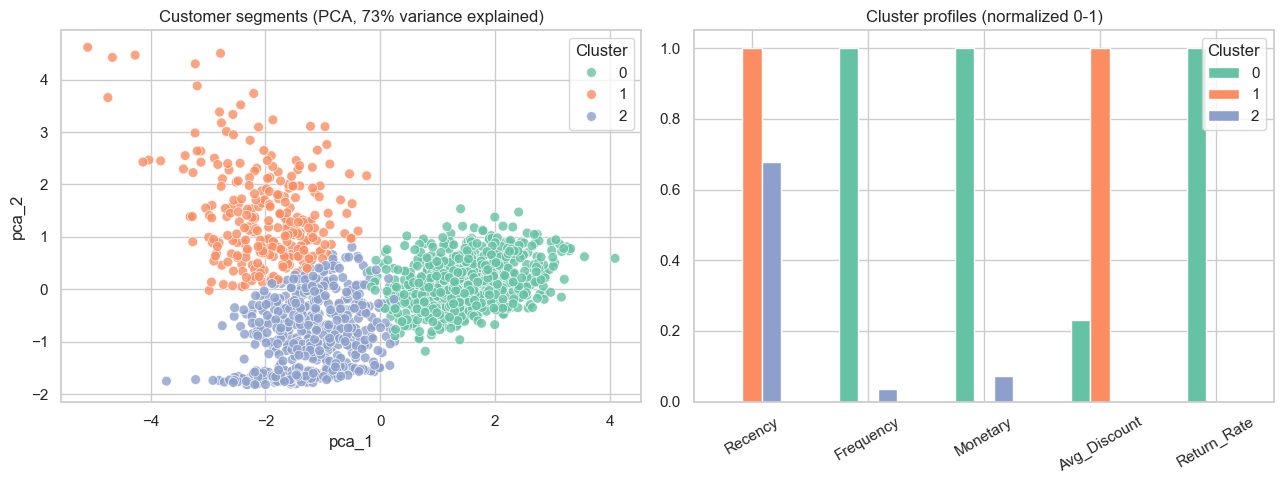

In [113]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
customer_features["pca_1"], customer_features["pca_2"] = coords[:, 0], coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=customer_features, x="pca_1", y="pca_2", hue="Cluster",
                 palette="Set2", s=50, alpha=0.8, ax=axes[0])
axes[0].set_title(f"Customer segments (PCA, {pca.explained_variance_ratio_.sum():.0%} variance explained)")

normalized = (cluster_summary[profile_cols] - cluster_summary[profile_cols].min()) / \
             (cluster_summary[profile_cols].max() - cluster_summary[profile_cols].min())
normalized.T.plot(kind="bar", ax=axes[1], color=sns.color_palette("Set2", n_colors=3))
axes[1].set_title("Cluster profiles (normalized 0-1)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Cluster")

plt.tight_layout()
plt.show()

- **Best customers:** low Recency (bought recently), high Frequency, high Monetary, lower average discount and return rate — the most reliable, most valuable group.
- **Occasional customers:** moderate on everything — buy sometimes, spend a moderate amount, not particularly discount-driven.
- **At-risk / discount-driven customers:** high Recency (haven't purchased in a while) and/or a noticeably higher average discount or return rate — either drifting away, or mainly shopping around promotions.